# Predicting individual medical insurance charges

Regression on 1,338 policyholder records: which factors drive the bill, and how well can we predict it?

Author: MD. Sakib Al Hasan

## What am I trying to predict?

Target is `charges`, the yearly medical cost billed for a person. It's a continuous number, so this is a **regression** problem.

I'll judge models on three metrics, not one:
- **RMSE** - punishes big misses, in dollars
- **MAE** - the typical miss, in dollars, easier to explain to a non-technical person
- **R²** - share of variance explained

The 20% test set stays untouched until the very end.

In [1]:
import sys, json, warnings
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from scipy import stats
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from src.preprocessing import add_features, build_pipeline, CATEGORICAL, TARGET

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
FIG = '../reports/figures/'

def savefig(name):
    plt.savefig(FIG + name, dpi=130, bbox_inches='tight')

## Loading the data

In [2]:
df_raw = pd.read_csv('../data/insurance.csv')
print('shape:', df_raw.shape)
df_raw.head()

shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Seven columns, no ID column, no dates, no free text. Nothing to drop up front.

| Column | Type | Role |
|---|---|---|
| age | numeric | feature |
| sex | categorical (2) | feature |
| bmi | numeric | feature |
| children | numeric (count) | feature |
| smoker | categorical (2) | feature |
| region | categorical (4) | feature |
| charges | numeric | **target** |

## Missing values and duplicates

In [4]:
print('missing per column:')
print(df_raw.isnull().sum())
print()
n_dup = df_raw.duplicated().sum()
print('duplicated rows:', n_dup)
df_raw[df_raw.duplicated(keep=False)]

missing per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

duplicated rows: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


No missing values, so no imputation needed. There's one exact duplicate row (two identical 19-year-old males). With 1,338 rows and continuous `charges` down to the cent, two identical records is almost certainly an entry error, so I'm dropping one copy.

In [5]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print('rows after dropping duplicate:', len(df))
df.describe().round(2)

rows after dropping duplicate: 1337


,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [6]:
for col in ['sex', 'smoker', 'region']:
    print(df[col].value_counts(), '\n')

sex
male      675
female    662
Name: count, dtype: int64 

smoker
no     1063
yes     274
Name: count, dtype: int64 

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64 



## The target: is `charges` skewed?

skewness of charges:        1.52
skewness of log(charges):   -0.09


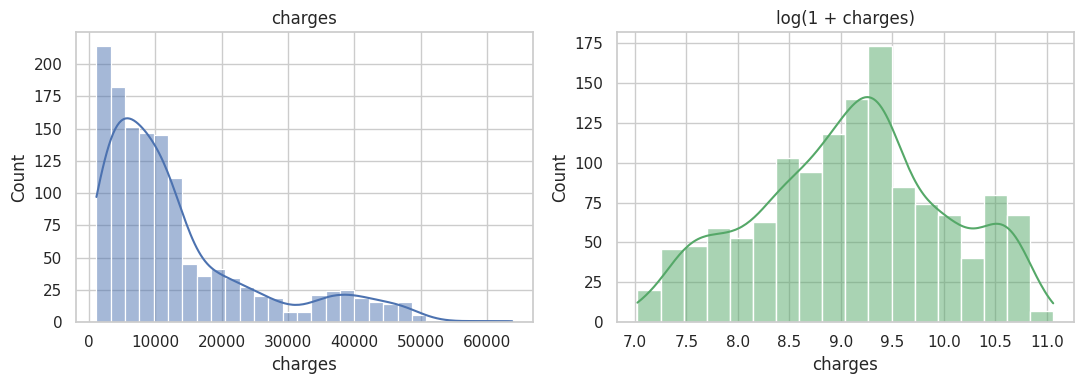

In [7]:
skew_raw = df['charges'].skew()
skew_log = np.log1p(df['charges']).skew()
print(f'skewness of charges:        {skew_raw:.2f}')
print(f'skewness of log(charges):   {skew_log:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['charges'], kde=True, ax=ax[0], color='#4C72B0')
ax[0].set_title('charges')
sns.histplot(np.log1p(df['charges']), kde=True, ax=ax[1], color='#55A868')
ax[1].set_title('log(1 + charges)')
plt.tight_layout(); savefig('01_target_distribution.png'); plt.show()

Right-skewed, long tail of very expensive cases. The log version is close to symmetric. I'll test a log-target linear model later to see if it actually helps, rather than assuming it does.

## Univariate look at the features

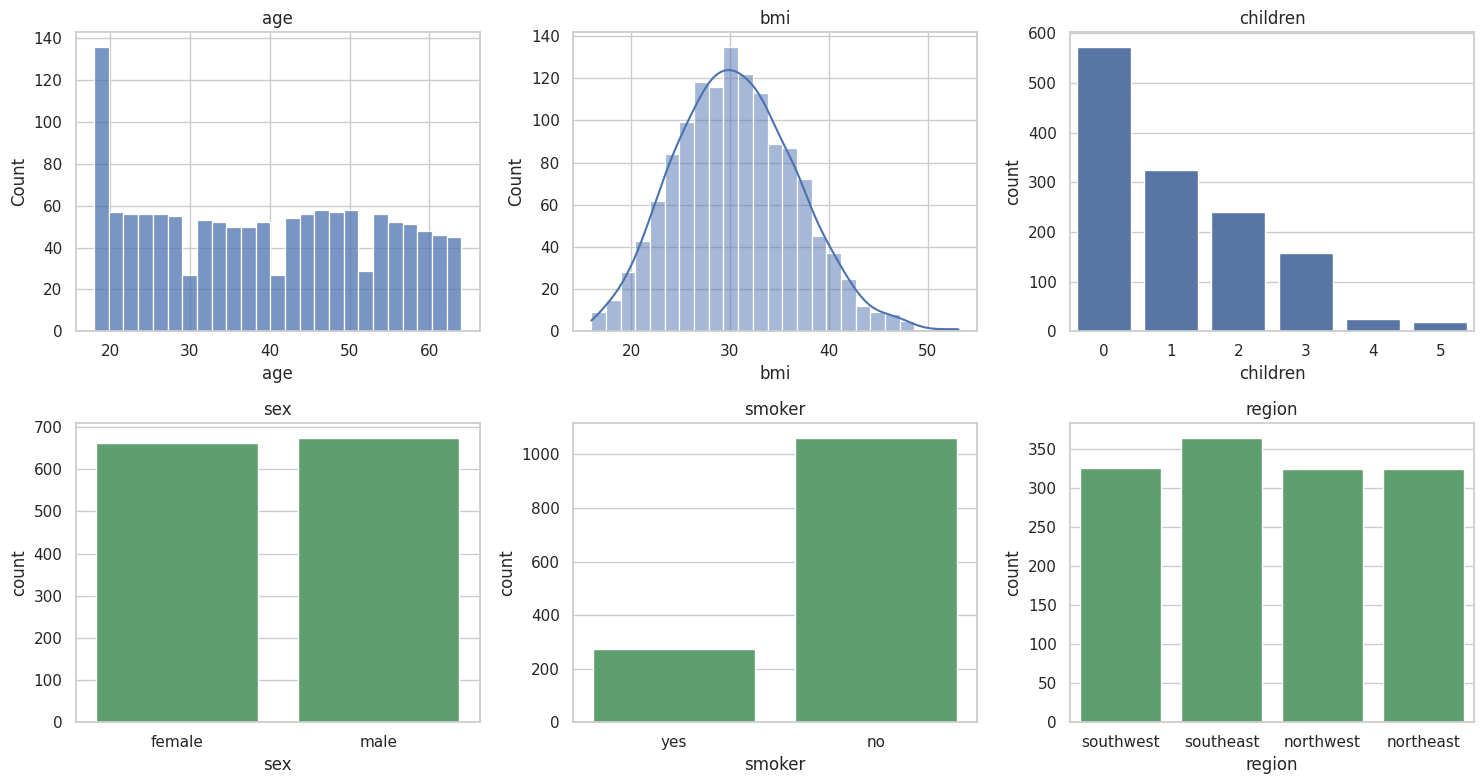

smokers: 20.5% of records
bmi skewness: 0.28, age skewness: 0.05
share with bmi >= 30: 52.8%


In [8]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(df['age'], bins=25, ax=ax[0, 0], color='#4C72B0'); ax[0, 0].set_title('age')
sns.histplot(df['bmi'], kde=True, ax=ax[0, 1], color='#4C72B0'); ax[0, 1].set_title('bmi')
sns.countplot(x=df['children'], ax=ax[0, 2], color='#4C72B0'); ax[0, 2].set_title('children')
sns.countplot(x=df['sex'], ax=ax[1, 0], color='#55A868'); ax[1, 0].set_title('sex')
sns.countplot(x=df['smoker'], ax=ax[1, 1], color='#55A868'); ax[1, 1].set_title('smoker')
sns.countplot(x=df['region'], ax=ax[1, 2], color='#55A868'); ax[1, 2].set_title('region')
plt.tight_layout(); savefig('02_univariate.png'); plt.show()

print(f"smokers: {(df['smoker'] == 'yes').mean():.1%} of records")
print(f"bmi skewness: {df['bmi'].skew():.2f}, age skewness: {df['age'].skew():.2f}")
print(f"share with bmi >= 30: {(df['bmi'] >= 30).mean():.1%}")

Age is fairly flat from 18 to 64 apart from a spike at 18-19, and BMI is roughly bell-shaped and centred around 30. Only about one in five people smoke, which matters: any model has to learn a big effect from a fairly small group.

## Bivariate: what moves the bill?

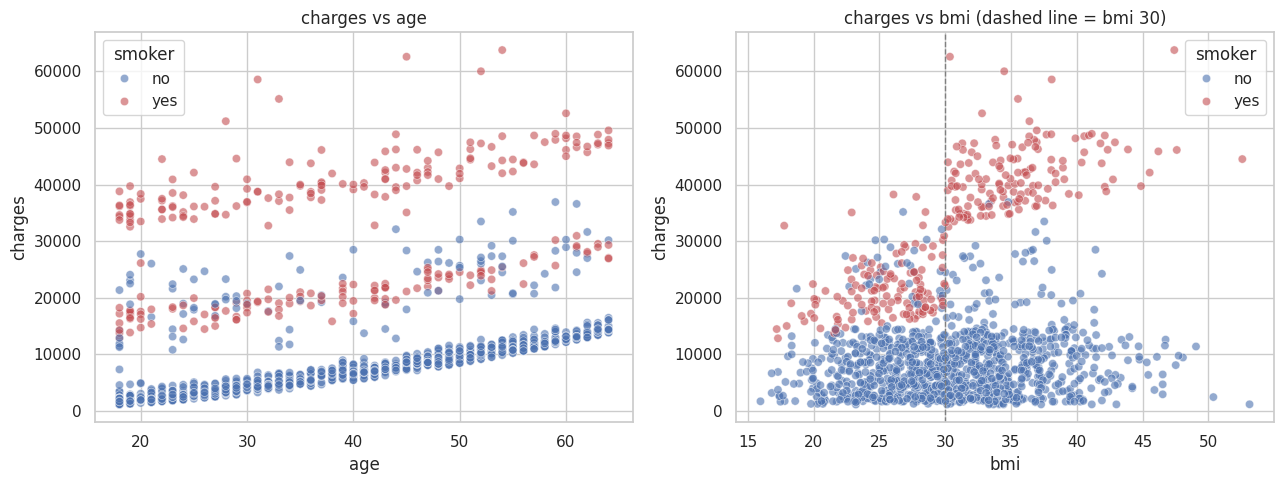

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', hue_order=['no', 'yes'], alpha=0.6, ax=ax[0], palette=['#4C72B0', '#C44E52'])
ax[0].set_title('charges vs age')
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', hue_order=['no', 'yes'], alpha=0.6, ax=ax[1], palette=['#4C72B0', '#C44E52'])
ax[1].axvline(30, color='grey', ls='--', lw=1)
ax[1].set_title('charges vs bmi (dashed line = bmi 30)')
plt.tight_layout(); savefig('03_age_bmi_vs_charges.png'); plt.show()

Two things jump out. In the age plot, charges climb steadily with age in three loose bands, and the top band is smokers only. In the BMI plot, non-smokers show no obvious trend at all, while smokers above BMI 30 jump into a much higher cluster than smokers below it. So BMI seems to matter mostly *for smokers*, which is an interaction a plain linear model won't pick up by itself.

        count     mean   median
smoker                         
no       1063   8441.0   7346.0
yes       274  32050.0  34456.0



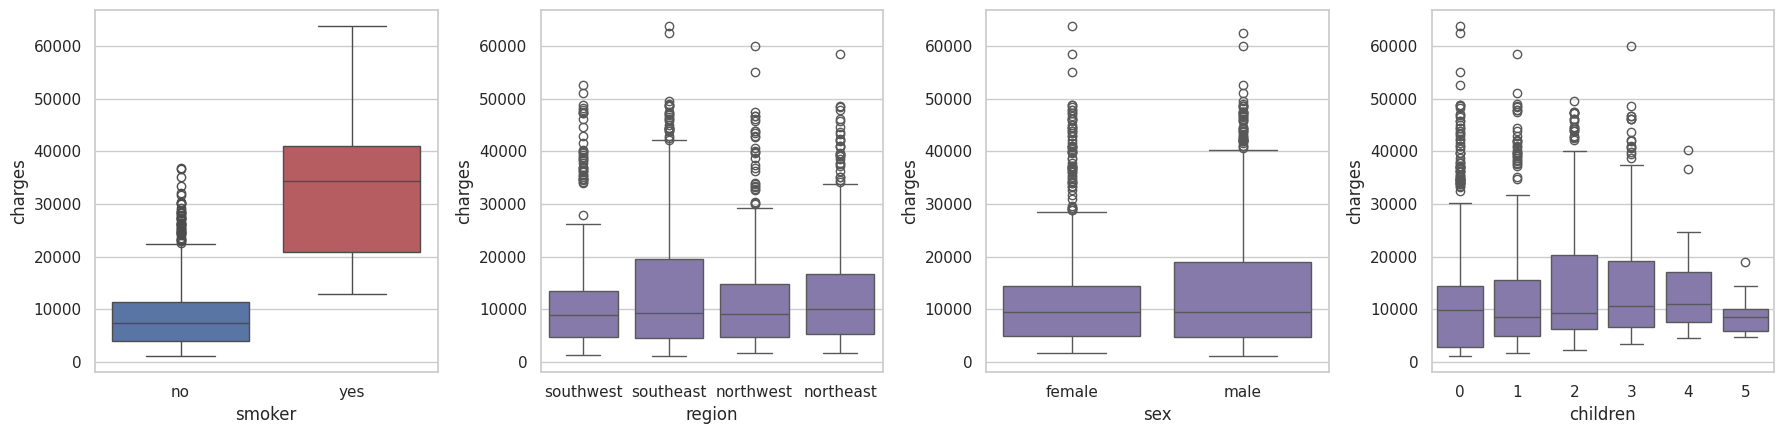

region
northeast    13406.0
northwest    12451.0
southeast    14735.0
southwest    12347.0
Name: charges, dtype: float64
sex
female    12570.0
male      13975.0
Name: charges, dtype: float64


In [10]:
print(df.groupby('smoker')['charges'].agg(['count', 'mean', 'median']).round(0))
print()

fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
sns.boxplot(data=df, x='smoker', y='charges', order=['no', 'yes'], ax=ax[0], palette=['#4C72B0', '#C44E52'])
sns.boxplot(data=df, x='region', y='charges', ax=ax[1], color='#8172B2')
sns.boxplot(data=df, x='sex', y='charges', ax=ax[2], color='#8172B2')
sns.boxplot(data=df, x='children', y='charges', ax=ax[3], color='#8172B2')
plt.tight_layout(); savefig('04_categorical_vs_charges.png'); plt.show()

print(df.groupby('region')['charges'].mean().round(0))
print(df.groupby('sex')['charges'].mean().round(0))

Smoker status is the big separator by far. Region, sex and number of children barely shift the distribution. I'll keep them in the model anyway and let the results (and SHAP later) say how much they count.

Now the smoker x obesity idea:

In [11]:
tmp = df.assign(obese=np.where(df['bmi'] >= 30, 'bmi >= 30', 'bmi < 30'))
summary = tmp.groupby(['smoker', 'obese'])['charges'].agg(['count', 'mean']).round(0)
print(summary)

ratio = summary.loc[('yes', 'bmi >= 30'), 'mean'] / summary.loc[('yes', 'bmi < 30'), 'mean']
ratio_ns = summary.loc[('no', 'bmi >= 30'), 'mean'] / summary.loc[('no', 'bmi < 30'), 'mean']
print(f'\nobese vs non-obese, smokers:     x{ratio:.2f}')
print(f'obese vs non-obese, non-smokers: x{ratio_ns:.2f}')

                  count     mean
smoker obese                    
no     bmi < 30     502   7977.0
       bmi >= 30    561   8856.0
yes    bmi < 30     129  21363.0
       bmi >= 30    145  41558.0

obese vs non-obese, smokers:     x1.95
obese vs non-obese, non-smokers: x1.11


For non-smokers, being obese barely changes the average bill. For smokers it nearly doubles it. That's the case for an explicit `smoker_obese` feature. I'll test whether it actually helps before claiming it does.

## Outliers

In [12]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

rows = []
for col in ['charges', 'bmi', 'age']:
    lo, hi = iqr_bounds(df[col])
    n_iqr = ((df[col] < lo) | (df[col] > hi)).sum()
    n_z = (np.abs(stats.zscore(df[col])) > 3).sum()
    rows.append({'column': col, 'IQR outliers': n_iqr, 'Z>3 outliers': n_z})
print(pd.DataFrame(rows).to_string(index=False))

lo, hi = iqr_bounds(df['charges'])
out = df[df['charges'] > hi]
print(f'\ncharges IQR upper fence: {hi:,.0f}')
print(f"of the {len(out)} high-charge outliers, {(out['smoker'] == 'yes').mean():.0%} are smokers")
print(f"of those, {(out['bmi'] >= 30).mean():.0%} have bmi >= 30")

 column  IQR outliers  Z>3 outliers
charges           139             7
    bmi             9             4
    age             0             0

charges IQR upper fence: 34,525
of the 139 high-charge outliers, 98% are smokers
of those, 96% have bmi >= 30


Most of the `charges` outliers are smokers, and mostly obese ones. They're not data errors, they're the exact group I want the model to understand. Removing or capping them would throw away the most important signal, so **I'm keeping every row**. The BMI outliers are few and plausible values (BMI in the low 50s is extreme but real).

## Correlation and multicollinearity

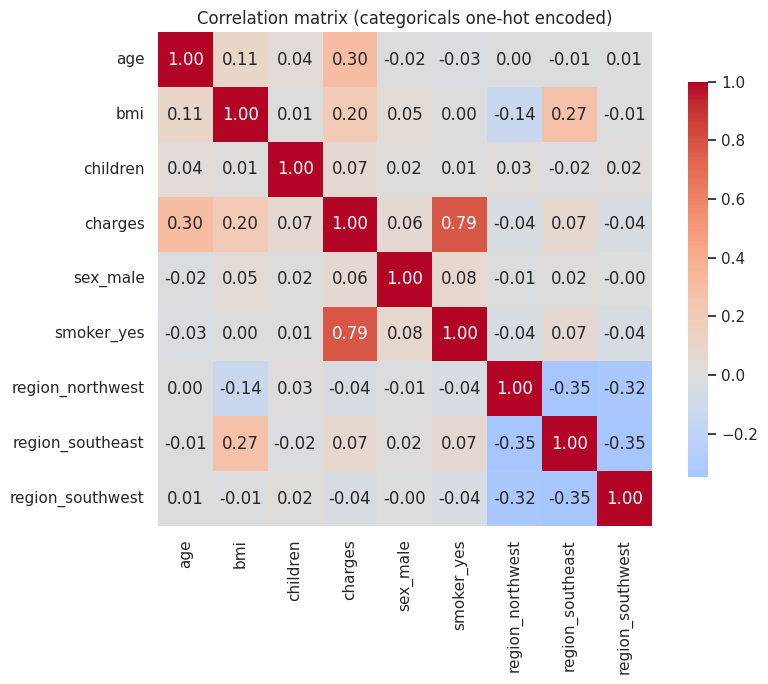

smoker_yes          0.787
age                 0.298
bmi                 0.198
region_southeast    0.074
children            0.067
sex_male            0.058
region_northwest   -0.039
region_southwest   -0.044
Name: charges, dtype: float64


In [13]:
enc = pd.get_dummies(df, drop_first=True, dtype=float)
corr = enc.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation matrix (categoricals one-hot encoded)')
plt.tight_layout(); savefig('05_correlation_heatmap.png'); plt.show()

print(corr['charges'].drop('charges').sort_values(ascending=False).round(3))

In [14]:
Xv = enc.drop(columns='charges')
Xv = Xv.assign(const=1.0)
vif = pd.DataFrame({
    'feature': Xv.columns,
    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
})
vif = vif[vif['feature'] != 'const'].sort_values('VIF', ascending=False)
print(vif.round(2).to_string(index=False))

         feature  VIF
region_southeast 1.65
region_southwest 1.53
region_northwest 1.52
             bmi 1.11
             age 1.02
      smoker_yes 1.01
        sex_male 1.01
        children 1.00


Smoker is the strongest single correlate with charges by a wide margin, then age, then BMI. All VIFs are low, so there's no multicollinearity problem in the raw features and nothing needs dropping. (The engineered `smoker_obese` column will overlap with `smoker`, but that's deliberate and tree models don't care.)

## Feature engineering

Two columns, both motivated by the plots above:

- `bmi_obese`: 1 if BMI >= 30
- `smoker_obese`: 1 if smoker and BMI >= 30

They're simple row-wise rules with no learned statistics, so they can't leak anything from the test set. They live in `src/preprocessing.py` and run as the first step of the pipeline.

In [15]:
add_features(df).head()

,age,sex,bmi,children,smoker,region,charges,bmi_obese,smoker_obese
0,19,female,27.900,0,yes,southwest,16884.92400,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


## Train / test split

80/20, stratified on `smoker` so both sides have the same smoker share. Validation happens inside the training set with 5-fold cross-validation, and the test set is only used at the end.

Encoding and scaling are inside the pipeline, so they get fitted on each training fold only. No leakage.

In [16]:
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=X['smoker']
)
print('train:', X_train.shape, ' test:', X_test.shape)
print(f"smoker share  train {(X_train['smoker'] == 'yes').mean():.3f} | test {(X_test['smoker'] == 'yes').mean():.3f}")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_eval(pipe):
    s = cross_validate(pipe, X_train, y_train, cv=kf, scoring={
        'r2': 'r2', 'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error'})
    return {'R2': s['test_r2'].mean(), 'R2 std': s['test_r2'].std(),
            'RMSE': -s['test_rmse'].mean(), 'MAE': -s['test_mae'].mean()}

train: (1069, 6)  test: (268, 6)
smoker share  train 0.205 | test 0.205


## Baselines, and did the engineered features help?

First a dummy model that always predicts the mean (this is the floor everything has to beat), then plain linear regression with and without my two engineered columns.

In [17]:
raw_prep = ColumnTransformer([
    ('num', StandardScaler(), ['age', 'bmi', 'children']),
    ('cat', OneHotEncoder(drop='first'), CATEGORICAL),
])
lr_raw = Pipeline([('prep', raw_prep), ('model', LinearRegression())])
lr_fe = build_pipeline(LinearRegression())

ablation = pd.DataFrame({
    'Dummy (mean)': cv_eval(build_pipeline(DummyRegressor())),
    'Linear, raw features': cv_eval(lr_raw),
    'Linear, + engineered features': cv_eval(lr_fe),
}).T
ablation.round(3)

,R2,R2 std,RMSE,MAE
Dummy (mean),-0.015,0.014,12098.178,9155.457
"Linear, raw features",0.722,0.036,6297.118,4392.589
"Linear, + engineered features",0.842,0.038,4715.179,2694.463


In [18]:
gain = 1 - ablation.loc['Linear, + engineered features', 'RMSE'] / ablation.loc['Linear, raw features', 'RMSE']
print(f'RMSE drop from engineered features (linear model): {gain:.1%}')

RMSE drop from engineered features (linear model): 25.1%


The two extra columns clearly help the linear model, which supports the interaction I spotted in the EDA. I'm keeping them for every model so the comparison is fair.

## Comparing models with cross-validation

Eight candidates, all with default-ish settings, same 5 folds. Scaling only for the models that need it (linear, Ridge, KNN).

In [19]:
candidates = {
    'Linear Regression':          build_pipeline(LinearRegression()),
    'Linear (log target)':        build_pipeline(TransformedTargetRegressor(LinearRegression(), func=np.log1p, inverse_func=np.expm1)),
    'Ridge':                      build_pipeline(Ridge(alpha=1.0)),
    'KNN':                        build_pipeline(KNeighborsRegressor(n_neighbors=7)),
    'Decision Tree':              build_pipeline(DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE), scale=False),
    'Random Forest':              build_pipeline(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), scale=False),
    'Gradient Boosting':          build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE), scale=False),
    'XGBoost':                    build_pipeline(XGBRegressor(random_state=RANDOM_STATE), scale=False),
}

cv_results = pd.DataFrame({name: cv_eval(p) for name, p in candidates.items()}).T.sort_values('RMSE')
cv_results.round(3)

,R2,R2 std,RMSE,MAE
Ridge,0.842,0.038,4715.000,2702.270
Linear Regression,0.842,0.038,4715.179,2694.463
Gradient Boosting,0.835,0.044,4818.049,2768.802
Random Forest,0.816,0.053,5069.454,2923.358
Decision Tree,0.812,0.042,5158.769,3059.784
KNN,0.801,0.038,5314.264,3311.062
XGBoost,0.791,0.063,5387.409,3159.616
Linear (log target),0.469,0.079,8762.467,4256.123


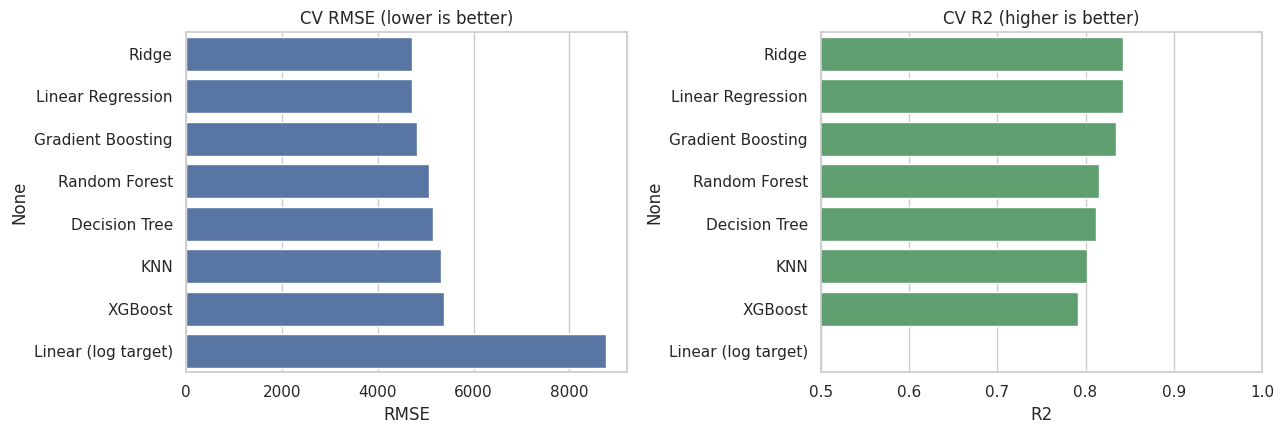

In [20]:
cv_results.to_csv('../reports/cv_model_comparison.csv')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
order = cv_results.index
sns.barplot(x=cv_results['RMSE'], y=order, ax=ax[0], color='#4C72B0'); ax[0].set_title('CV RMSE (lower is better)')
sns.barplot(x=cv_results['R2'], y=order, ax=ax[1], color='#55A868'); ax[1].set_title('CV R2 (higher is better)')
ax[1].set_xlim(0.5, 1)
plt.tight_layout(); savefig('06_model_comparison_cv.png'); plt.show()

Bit of a surprise here: plain linear regression (with the two engineered features) is the best of the default models, Ridge is identical, and Gradient Boosting is right behind. The gaps between the top few are well inside fold-to-fold noise (R2 std is roughly 0.04), so none of them is a clear winner yet.

Log-transforming the target made the linear model much *worse* on dollar metrics (R2 about 0.47). Probably because converting log-predictions back to dollars overshoots on the biggest bills, and RMSE punishes exactly that. Dropping that idea.

The ensembles have the most room to improve with tuning, so those three go to the next step.

## Hyperparameter tuning

Gradient Boosting gets a full grid (small space). Random Forest and XGBoost get randomized search since their spaces are bigger. Scoring is RMSE, same 5 folds.

In [21]:
gb_search = GridSearchCV(
    build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE), scale=False),
    param_grid={
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__min_samples_leaf': [5, 15],
    },
    cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1,
).fit(X_train, y_train)
print('Gradient Boosting  best CV RMSE:', round(-gb_search.best_score_, 1))
print(gb_search.best_params_)

Gradient Boosting  best CV RMSE: 4699.9
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 15, 'model__n_estimators': 100}


In [22]:
rf_search = RandomizedSearchCV(
    build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE), scale=False),
    param_distributions={
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [3, 4, 5, 6, 8, None],
        'model__min_samples_leaf': [1, 3, 5, 10, 15],
        'model__max_features': [0.5, 0.7, 1.0],
    },
    n_iter=25, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)
print('Random Forest  best CV RMSE:', round(-rf_search.best_score_, 1))
print(rf_search.best_params_)

Random Forest  best CV RMSE: 4714.3
{'model__n_estimators': 500, 'model__min_samples_leaf': 5, 'model__max_features': 0.7, 'model__max_depth': 6}


In [23]:
xgb_search = RandomizedSearchCV(
    build_pipeline(XGBRegressor(random_state=RANDOM_STATE), scale=False),
    param_distributions={
        'model__n_estimators': [100, 200, 300, 500],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4, 5],
        'model__min_child_weight': [1, 3, 5, 10],
        'model__subsample': [0.7, 0.85, 1.0],
        'model__colsample_bytree': [0.7, 0.85, 1.0],
        'model__reg_lambda': [0.5, 1, 5, 10],
    },
    n_iter=40, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=RANDOM_STATE,
).fit(X_train, y_train)
print('XGBoost  best CV RMSE:', round(-xgb_search.best_score_, 1))
print(xgb_search.best_params_)

XGBoost  best CV RMSE: 4696.3
{'model__subsample': 0.85, 'model__reg_lambda': 10, 'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}


In [24]:
tuned = {'Gradient Boosting': gb_search, 'Random Forest': rf_search, 'XGBoost': xgb_search}

tuned_cv = pd.DataFrame({
    name: {'CV RMSE (default)': cv_results.loc[name, 'RMSE'],
           'CV RMSE (tuned)': -s.best_score_}
    for name, s in tuned.items()
}).T
tuned_cv['improvement'] = 1 - tuned_cv['CV RMSE (tuned)'] / tuned_cv['CV RMSE (default)']
tuned_cv.to_csv('../reports/tuning_results.csv')
tuned_cv.round(3)

,CV RMSE (default),CV RMSE (tuned),improvement
Gradient Boosting,4818.049,4699.867,0.025
Random Forest,5069.454,4714.348,0.070
XGBoost,5387.409,4696.316,0.128


Tuning helped XGBoost the most (about 13% lower CV RMSE), but all three ensembles end up around 4,700. That's essentially where plain linear regression already was (about 4,715). The extra complexity buys very little on this dataset.

## Final model selection and the test set

Picking the winner by **cross-validated RMSE on the training set only**. Only then do I look at the test set, and I score every tuned model there so the comparison is transparent, but the choice was already made.

In [25]:
best_name = max(tuned, key=lambda n: tuned[n].best_score_)
best_model = tuned[best_name].best_estimator_
print('selected model:', best_name)

def score(pipe, Xa, ya):
    p = pipe.predict(Xa)
    return {'R2': r2_score(ya, p), 'RMSE': np.sqrt(mean_squared_error(ya, p)), 'MAE': mean_absolute_error(ya, p)}

dummy = build_pipeline(DummyRegressor()).fit(X_train, y_train)
lin = build_pipeline(LinearRegression()).fit(X_train, y_train)

final = {'Dummy (mean)': score(dummy, X_test, y_test),
         'Linear Regression': score(lin, X_test, y_test)}
for n, s in tuned.items():
    final[f'{n} (tuned)'] = score(s.best_estimator_, X_test, y_test)

test_df = pd.DataFrame(final).T
test_df.to_csv('../reports/test_results.csv')
test_df.round(3)

selected model: XGBoost


,R2,RMSE,MAE
Dummy (mean),-0.001,12012.592,9080.773
Linear Regression,0.918,3439.587,2139.779
Gradient Boosting (tuned),0.921,3384.268,2116.384
Random Forest (tuned),0.922,3357.255,2098.872
XGBoost (tuned),0.921,3372.558,2074.363


In [26]:
tr, te = score(best_model, X_train, y_train), score(best_model, X_test, y_test)
print(f'{best_name}: train R2 {tr["R2"]:.3f} vs test R2 {te["R2"]:.3f}')
print(f'train RMSE {tr["RMSE"]:,.0f} vs test RMSE {te["RMSE"]:,.0f}')
print(f'CV RMSE {-tuned[best_name].best_score_:,.0f}')

XGBoost: train R2 0.867 vs test R2 0.921
train RMSE 4,418 vs test RMSE 3,373
CV RMSE 4,696


In [27]:
from sklearn.base import clone

rows = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=X['smoker'])
    for name, est in [('Linear Regression', build_pipeline(LinearRegression())),
                      (f'{best_name} (tuned)', clone(best_model))]:
        est.fit(Xa, ya)
        rows.append({'model': name, 'seed': seed, **score(est, Xb, yb)})

stab = pd.DataFrame(rows)
stab_summary = stab.groupby('model')[['R2', 'RMSE', 'MAE']].agg(['mean', 'std'])
stab_summary.columns = [f'{a} {b}' for a, b in stab_summary.columns]
print(stab_summary.round(3).to_string())

piv = stab.pivot(index='seed', columns='model', values='RMSE')
win_rate = (piv[f'{best_name} (tuned)'] < piv['Linear Regression']).mean()
print(f'\n{best_name} beats linear regression (lower RMSE) in {int(win_rate * 20)} of 20 splits')
stab_summary.to_csv('../reports/split_stability.csv')

                   R2 mean  R2 std  RMSE mean  RMSE std  MAE mean  MAE std
model                                                                     
Linear Regression    0.852   0.033   4591.353   541.725  2497.643  215.495
XGBoost (tuned)      0.854   0.032   4564.636   534.533  2511.531  200.868

XGBoost beats linear regression (lower RMSE) in 13 of 20 splits


Worth being upfront about: the hyperparameters were picked using the original training split, so this slightly favours the tuned model. Even so, the two models end up close. One split is one draw, so the averages and spread from this table are the numbers I'd quote, not the single 0.921.

XGBoost, Gradient Boosting and Random Forest are separated by under 0.4% in CV RMSE (4,696 / 4,700 / 4,714). That's a coin flip. The rule was CV RMSE, so XGBoost is the pick. Random Forest scored a hair better on the test set, but switching now would mean choosing on the test set, so I'm not.

Something else to flag: test RMSE (about 3,370) is *lower* than CV RMSE (about 4,700), and test R2 is higher than train R2. That isn't leakage (the test set never touched training or tuning). The 268-row test set most likely just has fewer hard cases than average. So the CV figure is the more conservative expectation. To check how much a single split can move things, the next cell repeats the split 20 times.

## Where does the model go wrong?

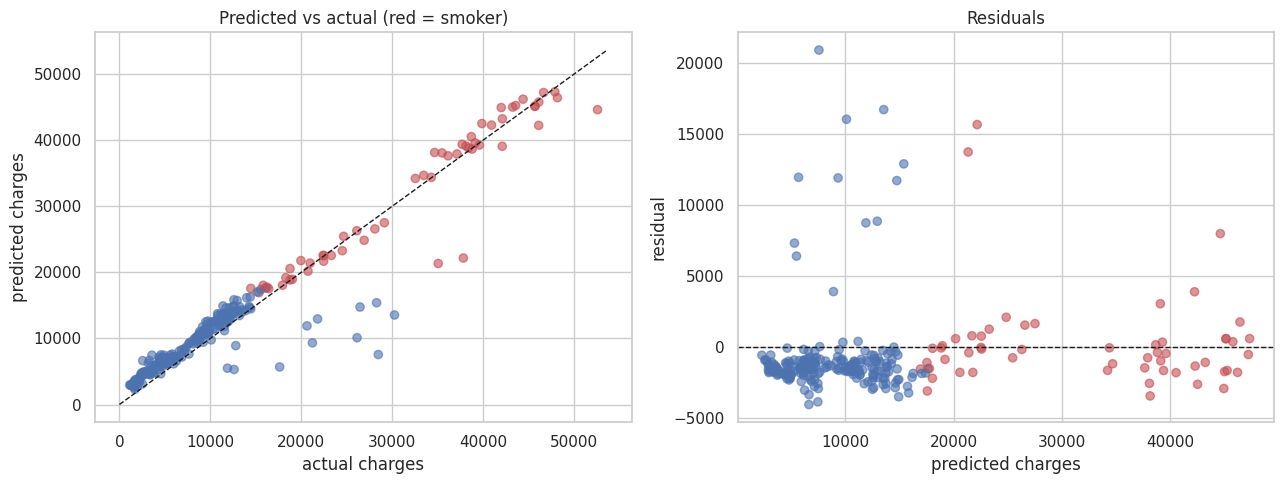

,n,MAE,mean_charge,MAE as % of mean charge
smoker,,,,
no,213,2124.0,7931.4,26.8
yes,55,1882.2,32496.6,5.8


In [28]:
pred = best_model.predict(X_test)
resid = y_test - pred

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_test, pred, alpha=0.6, c=np.where(X_test['smoker'] == 'yes', '#C44E52', '#4C72B0'))
lim = [0, max(y_test.max(), pred.max()) * 1.02]
ax[0].plot(lim, lim, 'k--', lw=1)
ax[0].set_xlabel('actual charges'); ax[0].set_ylabel('predicted charges')
ax[0].set_title('Predicted vs actual (red = smoker)')
ax[1].scatter(pred, resid, alpha=0.6, c=np.where(X_test['smoker'] == 'yes', '#C44E52', '#4C72B0'))
ax[1].axhline(0, color='k', ls='--', lw=1)
ax[1].set_xlabel('predicted charges'); ax[1].set_ylabel('residual')
ax[1].set_title('Residuals')
plt.tight_layout(); savefig('07_predicted_vs_actual.png'); plt.show()

err = pd.DataFrame({'smoker': X_test['smoker'].values, 'abs_err': np.abs(resid.values), 'actual': y_test.values})
by_group = err.groupby('smoker').agg(n=('abs_err', 'size'), MAE=('abs_err', 'mean'), mean_charge=('actual', 'mean'))
by_group['MAE as % of mean charge'] = by_group['MAE'] / by_group['mean_charge'] * 100
by_group.round(1)

In dollars the model actually misses smokers by *less* (MAE about 1.9k vs 2.1k), even though their bills are roughly four times bigger. In relative terms the gap is huge: about 6% of the average bill for smokers against about 27% for non-smokers. So the weak spot is non-smokers, whose bills are small but noisy compared to their size.

## What is the model actually using? (SHAP)

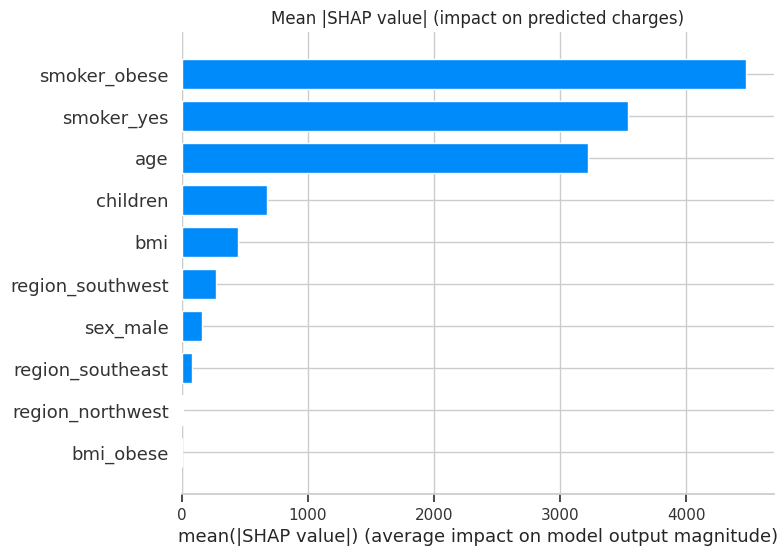

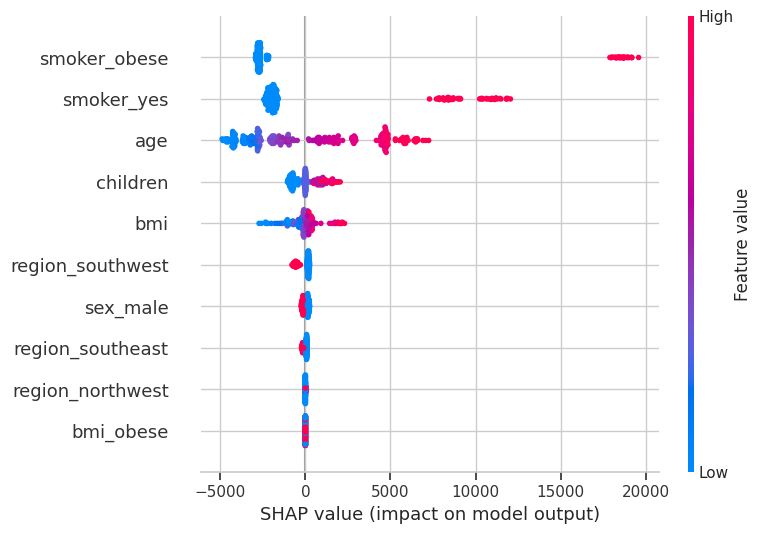

smoker_obese        4472.0
smoker_yes          3537.0
age                 3223.0
children             676.0
bmi                  448.0
region_southwest     267.0
sex_male             163.0
region_southeast      78.0
region_northwest       8.0
bmi_obese              0.0
dtype: float32


In [29]:
prep = best_model.named_steps['prep']
Xt = pd.DataFrame(prep.transform(best_model.named_steps['fe'].transform(X_test)),
                  columns=[c.split('__')[-1] for c in prep.get_feature_names_out()])

explainer = shap.TreeExplainer(best_model.named_steps['model'])
sv = explainer.shap_values(Xt)

shap.summary_plot(sv, Xt, plot_type='bar', show=False)
plt.title('Mean |SHAP value| (impact on predicted charges)')
savefig('08_shap_importance.png'); plt.show()

shap.summary_plot(sv, Xt, show=False)
savefig('09_shap_beeswarm.png'); plt.show()

shap_rank = pd.Series(np.abs(sv).mean(axis=0), index=Xt.columns).sort_values(ascending=False)
print(shap_rank.round(0))

Two smoker features and age carry nearly all the signal (mean |SHAP| roughly 4,470 / 3,540 / 3,220). Children is a distant fourth at about 680, and BMI, region and sex are close to negligible. `bmi_obese` gets exactly zero, presumably because `smoker_obese` already covers what it would add, and raw BMI looks weak for the same reason: its effect is captured through `smoker_obese`. This matches what the EDA suggested.

## Saving the model

In [30]:
joblib.dump(best_model, '../models/model_pipeline.pkl')

params = {k.replace('model__', ''): (v.item() if hasattr(v, 'item') else v)
          for k, v in tuned[best_name].best_params_.items()}
json.dump({'model': best_name, 'params': params}, open('../reports/best_params.json', 'w'), indent=2)

metrics = {'selected_model': best_name,
           'cv_rmse': -tuned[best_name].best_score_,
           'test': te, 'train': tr}
json.dump(metrics, open('../reports/metrics.json', 'w'), indent=2)

# reload and predict on two made-up people (same profile, only smoking differs)
reloaded = joblib.load('../models/model_pipeline.pkl')
demo = pd.DataFrame([
    {'age': 35, 'sex': 'male', 'bmi': 32.0, 'children': 1, 'smoker': 'yes', 'region': 'southeast'},
    {'age': 35, 'sex': 'male', 'bmi': 32.0, 'children': 1, 'smoker': 'no',  'region': 'southeast'},
])
demo['predicted_charges'] = reloaded.predict(demo).round(0)
demo

,age,sex,bmi,children,smoker,region,predicted_charges
0,35,male,32.0,1,yes,southeast,39030.0
1,35,male,32.0,1,no,southeast,6447.0


## Summary

In [31]:
lin_t, best_t = final['Linear Regression'], final[f'{best_name} (tuned)']
top3 = ', '.join(shap_rank.index[:3])
display(Markdown(f'''
**Selected model:** {best_name} (tuned), chosen on cross-validated RMSE

- Averaged over 20 random 80/20 splits: R2 **{stab_summary.loc[f"{best_name} (tuned)", "R2 mean"]:.3f}**, RMSE **${stab_summary.loc[f"{best_name} (tuned)", "RMSE mean"]:,.0f}** (std ${stab_summary.loc[f"{best_name} (tuned)", "RMSE std"]:,.0f}), MAE **${stab_summary.loc[f"{best_name} (tuned)", "MAE mean"]:,.0f}**
- Plain linear regression, same 20 splits: R2 {stab_summary.loc["Linear Regression", "R2 mean"]:.3f}, RMSE ${stab_summary.loc["Linear Regression", "RMSE mean"]:,.0f}
- The original split gave R2 {best_t["R2"]:.3f} / RMSE ${best_t["RMSE"]:,.0f}, which turned out to be a favourable draw. 5-fold CV RMSE on the training set was ${-tuned[best_name].best_score_:,.0f}
- Top SHAP features: {top3}
- Smokers average about ${summary.loc[("yes", "bmi < 30"), "mean"]:,.0f} (bmi < 30) and ${summary.loc[("yes", "bmi >= 30"), "mean"]:,.0f} (bmi >= 30) versus roughly ${df.loc[df["smoker"] == "no", "charges"].mean():,.0f} for non-smokers

Caveats: the tuned ensemble beats linear regression by only a small margin here, so a simple model is a reasonable choice if interpretability matters. 1,337 rows is small, and the data has no diagnosis, claims history or plan details, so this is a pricing-factor model, not a clinical one.
'''))


**Selected model:** XGBoost (tuned), chosen on cross-validated RMSE

- Averaged over 20 random 80/20 splits: R2 **0.854**, RMSE **$4,565** (std $535), MAE **$2,512**
- Plain linear regression, same 20 splits: R2 0.852, RMSE $4,591
- The original split gave R2 0.921 / RMSE $3,373, which turned out to be a favourable draw. 5-fold CV RMSE on the training set was $4,696
- Top SHAP features: smoker_obese, smoker_yes, age
- Smokers average about $21,363 (bmi < 30) and $41,558 (bmi >= 30) versus roughly $8,441 for non-smokers

Caveats: the tuned ensemble beats linear regression by only a small margin here, so a simple model is a reasonable choice if interpretability matters. 1,337 rows is small, and the data has no diagnosis, claims history or plan details, so this is a pricing-factor model, not a clinical one.
